In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Objects

Let's fetch some active object:

In [2]:
from raprock.neoscan import get_objects

objects = get_objects()
print(f"The first ten objects are:\n\n{', '.join(objects[:10])}")

The first ten objects are:

gb00832, gb00831, TF26CD0, C462CX1, 8MRA001, TF26CE7, ZTF10CO, ST26C87, C19RNP5, CEC7CG2


# Ephemerides

Now query for topocentrical ephemerides at LBT observatory.

In [14]:
from raprock.neoscan import get_ephemeris
from raprock.observatories import LBT


OBJ = "C19RNP5"
df = get_ephemeris(
    object_name=OBJ,
    observatory=LBT,
    tstart="2026-03-20T12:00",
    tend="2026-03-24T18:00",
    deltat=15, # minutes
)

In [15]:
df

,Object,Obs_name,Obs_code,Mag,Alt,Azi,Airmass,Sun_elev,SolEl,LunEl,...,Glat,Glon,R,Delta,RA_deg,DEC_deg,MJD,RA_rate_deg,DEC_rate_deg,Vel_deg
0,C19RNP5,LBT,G83,19.5,66.6,36.6,1.090,-18.2,90.1,93.1,...,28.7,77.2,3.6979,3.5597,269.629854,49.784969,61119.500000,0.000114,0.000232,0.000259
1,C19RNP5,LBT,G83,19.5,68.4,32.3,1.075,-15.1,90.1,93.2,...,28.7,77.2,3.6978,3.5596,269.632496,49.788456,61119.510417,0.000114,0.000232,0.000259
2,C19RNP5,LBT,G83,19.5,70.0,27.1,1.064,-12.0,90.1,93.2,...,28.7,77.2,3.6977,3.5594,269.635133,49.791939,61119.520833,0.000114,0.000232,0.000258
3,C19RNP5,LBT,G83,19.5,71.3,20.9,1.056,-8.9,90.1,93.2,...,28.7,77.2,3.6976,3.5593,269.637771,49.795422,61119.531250,0.000114,0.000232,0.000258
4,C19RNP5,LBT,G83,19.5,72.2,13.8,1.050,-5.7,90.1,93.3,...,28.7,77.2,3.6976,3.5592,269.640408,49.798903,61119.541667,0.000113,0.000232,0.000258
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
404,C19RNP5,LBT,G83,19.4,45.4,311.9,1.401,43.9,90.5,100.6,...,28.2,78.9,3.6615,3.5138,270.698217,51.201664,61123.708333,0.000107,0.000234,0.000257
405,C19RNP5,LBT,G83,19.4,43.1,311.9,1.461,46.4,90.5,100.6,...,28.2,78.9,3.6614,3.5137,270.700779,51.205175,61123.718750,0.000107,0.000234,0.000257
406,C19RNP5,LBT,G83,19.4,40.7,312.0,1.529,48.8,90.5,100.6,...,28.2,78.9,3.6613,3.5136,270.703346,51.208686,61123.729167,0.000107,0.000234,0.000257
407,C19RNP5,LBT,G83,19.4,38.4,312.3,1.606,51.1,90.5,100.5,...,28.2,78.9,3.6612,3.5135,270.705917,51.212194,61123.739583,0.000107,0.000234,0.000257


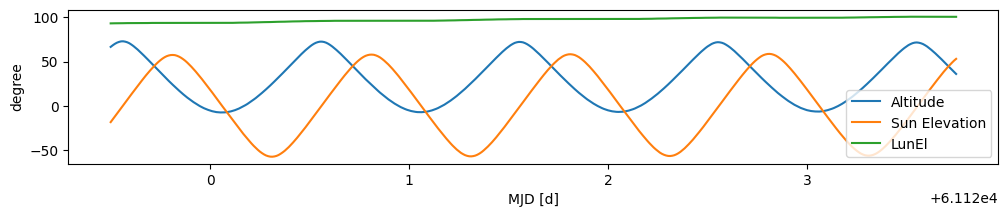

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 2))
plt.plot(df["MJD"], df["Alt"], label="Altitude")
plt.plot(df["MJD"], df["Sun_elev"], label="Sun Elevation")
plt.plot(df["MJD"], df["LunEl"], label="LunEl")
plt.xlabel("MJD [d]"); plt.ylabel("degree"); plt.legend(loc=4)
plt.show()


# Finding opportunity windows for observations

We will require:
1. the sun to have set (according to the astronomical definition of twilight).
2. the object to be higher than a threshold altitude at observatory.
3. enough time for exposure.

Given these, we find the opportunity windows for starting an object observation.

In [19]:
from raprock.pipes import after_twilight, not_moon_occulted, higher_than, longer_than, opportunity_windows

PHASE = "nautical"
MINH = 25 # degrees
EXPOSURE_LEN = 100 # minutes
_df = (df
    .pipe(after_twilight, phase=PHASE)
    .pipe(not_moon_occulted)
    .pipe(higher_than, deg=MINH)
    .pipe(longer_than, duration_min=EXPOSURE_LEN)
)
windows_df = opportunity_windows(_df, EXPOSURE_LEN)
windows_df

,Object,Obs_name,Obs_code,win_start,win_end,Alt_max,V_min,V_delta
0,C19RNP5,LBT,G83,61120.3125,61120.440972,68.5,19.5,0.0
1,C19RNP5,LBT,G83,61121.3125,61121.440972,68.5,19.4,0.1
2,C19RNP5,LBT,G83,61122.3125,61122.440972,68.5,19.4,0.0
3,C19RNP5,LBT,G83,61123.3125,61123.440972,68.6,19.4,0.0


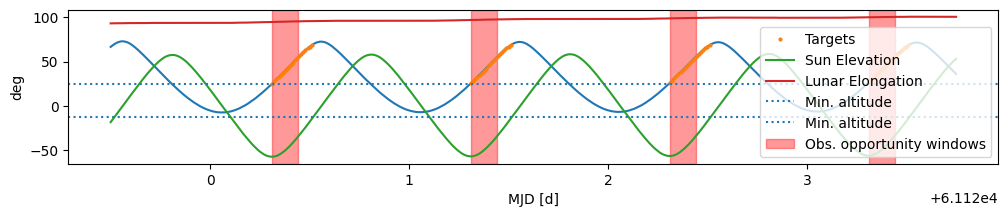

In [20]:
import matplotlib.pyplot as plt
from raprock.utils import TWILIGHTS


plt.figure(figsize=(12, 2))
plt.plot(df["MJD"], df["Alt"],)
plt.plot(_df["MJD"], _df["Alt"], "o", ms=2, label="Targets")
plt.plot(df["MJD"], df["Sun_elev"], label="Sun Elevation")
plt.plot(df["MJD"], df["LunEl"], label="Lunar Elongation")
plt.axhline(MINH, linestyle="dotted", label="Min. altitude")
plt.axhline(TWILIGHTS[PHASE], linestyle="dotted", label="Min. altitude")
label_set = False
for s, e in windows_df[["win_start", "win_end"]].values:
    plt.axvspan(s, e, label="Obs. opportunity windows" if not label_set else "", color="red", alpha=0.4)
    label_set = True
plt.xlabel("MJD [d]"); plt.ylabel("deg"); plt.legend(loc=4)
plt.show()

## Multiple objects and observatories

In [24]:
import pandas as pd
from time import sleep
from itertools import product
from tqdm.notebook import tqdm
from raprock.observatories import LBT, VST, CASSINI
from raprock.neoscan import get_ephemeris, EphEmptyError, EphFormatError


EXPOSURE_LEN = 100  # minutes

observatories = [LBT, VST, CASSINI]
combinations = list(product(objects[10:20], observatories))


dfs = {}
skipped_objects = set()
for obj, obs in tqdm(combinations, desc="Fetching ephemerides"):
    if obj in skipped_objects:
        tqdm.write(f"Skipping {obj} @ {obs}")
        continue
    try:
        sleep(0.5)
        dfs[(obj, obs)] = get_ephemeris(
            object_name=obj,
            observatory=obs,
            tstart="2026-03-20T20:00",
            tend="2026-03-24T18:00",
            deltat=15,  # minutes
        )
    except (EphEmptyError, EphFormatError) as e:
        tqdm.write(f"Skipping {obj} (bad ephemeris): {e}")
        skipped_objects.add(obj)
    except Exception as e:
        tqdm.write(f"Error fetching {obj} @ {obs}: {e}")

def filter_pipe(df):
    return (df
        .pipe(after_twilight, phase=PHASE)
        .pipe(not_moon_occulted)
        .pipe(higher_than, deg=MINH)
        .pipe(longer_than, duration_min=EXPOSURE_LEN)
    )

windows = pd.concat([opportunity_windows(filter_pipe(d), EXPOSURE_LEN) for d in dfs.values()])

Fetching ephemerides:   0%|          | 0/30 [00:00<?, ?it/s]

Skipping ST26C66 (bad ephemeris): Could not find separator line ('===')
Skipping ST26C66 @ Observatory(name='VST', code='309')
Skipping ST26C66 @ Observatory(name='CASSINI', code='598')
Skipping ZTF10Ch (bad ephemeris): The table does not contain numeric characters. Table content:

  Impact after the initial conditions
  Ephemerides not computed because of an impact

Skipping ZTF10Ch @ Observatory(name='VST', code='309')
Skipping ZTF10Ch @ Observatory(name='CASSINI', code='598')


In [25]:
windows

,Object,Obs_name,Obs_code,win_start,win_end,Alt_max,V_min,V_delta
0,C462EU1,LBT,G83,61120.166667,61120.368056,47.0,19.6,0.2
1,C462EU1,LBT,G83,61121.177083,61121.326389,39.5,20.2,0.1
2,C462EU1,LBT,G83,61122.177083,61122.284722,33.9,20.7,0.1
3,C462EU1,LBT,G83,61123.187500,61123.253472,29.7,21.2,0.0
0,C462EU1,VST,309,61120.020833,61120.305556,74.7,19.5,0.2
...,...,...,...,...,...,...,...,...
0,ZTF10Cg,VST,309,61120.177083,61120.336806,69.3,20.2,0.0
1,ZTF10Cg,VST,309,61121.218750,61121.336806,77.0,20.8,0.0
2,ZTF10Cg,VST,309,61122.291667,61122.336806,62.5,21.5,0.1
0,ZTF10Cg,CASSINI,598,61119.968750,61120.097222,41.9,20.0,0.1


In [26]:
windows.sort_values(by="win_start").groupby("Obs_name").first()

,Object,Obs_code,win_start,win_end,Alt_max,V_min,V_delta
Obs_name,,,,,,,
CASSINI,C1CHM75,598,61119.833333,61120.097222,84.2,23.2,0.0
LBT,C1CHM75,G83,61120.104167,61120.440972,84.0,23.2,0.0
VST,C462EU1,309,61120.020833,61120.305556,74.7,19.5,0.2


In [33]:
windows.sort_values(by="win_start").groupby("Object").first()

,Obs_name,Obs_code,win_start,win_end,Alt_max,V_min,V_delta
Object,,,,,,,
C1CHM75,CASSINI,598,61119.833333,61120.097222,84.2,23.2,0.0
C1CX3P5,CASSINI,598,61119.947917,61120.097222,80.5,22.8,0.0
C462EU1,CASSINI,598,61119.864583,61120.013889,38.3,19.4,0.1
CEDMYW2,CASSINI,598,61119.937500,61120.097222,57.1,20.5,0.0
CEEDQX2,CASSINI,598,61119.843750,61120.086806,50.6,21.0,0.1
CEEREM2,CASSINI,598,61119.864583,61120.034722,37.2,18.5,0.7
ST26C94,CASSINI,598,61119.833333,61120.097222,86.3,19.6,0.1
ZTF10Cg,CASSINI,598,61119.968750,61120.097222,41.9,20.0,0.1


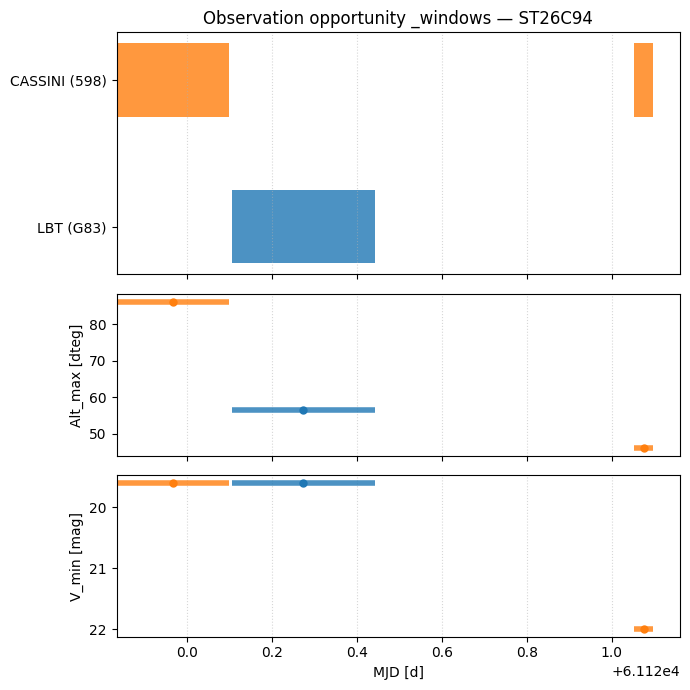

In [34]:
_OBJ = "ST26C94"
_windows = windows[windows["Object"] == _OBJ]

fig, axes = plt.subplots(3, 1, figsize=(7, 7), sharex=True, height_ratios=[3, 2, 2])

labels = (_windows["Obs_name"] + " (" + _windows["Obs_code"] + ")").unique()
y_pos = {label: i for i, label in enumerate(labels)}
colors = plt.cm.tab10.colors

for _, row in _windows.iterrows():
    label = f"{row['Obs_name']} ({row['Obs_code']})"
    y = y_pos[label]
    color = colors[y % len(colors)]
    mid = (row["win_start"] + row["win_end"]) / 2
    width = row["win_end"] - row["win_start"]

    axes[0].barh(y, width, left=row["win_start"], color=color, alpha=0.8, height=0.5)
    axes[1].hlines(row["Alt_max"], row["win_start"], row["win_end"], colors=color, linewidth=4, alpha=0.8)
    axes[1].plot(mid, row["Alt_max"], "o", color=color, ms=5)
    axes[2].hlines(row["V_min"], row["win_start"], row["win_end"], colors=color, linewidth=4, alpha=0.8)
    axes[2].plot(mid, row["V_min"], "o", color=color, ms=5)

axes[0].set_yticks(range(len(labels)))
axes[0].set_yticklabels(labels)
axes[1].set_ylabel("Alt_max [dteg]")
axes[2].set_ylabel("V_min [mag]")
axes[2].invert_yaxis()  # brighter = lower mag = top of axis
axes[2].set_xlabel("MJD [d]")
axes[0].set_title(f"Observation opportunity _windows — {_OBJ}")

for ax in axes:
    ax.grid(axis="x", linestyle="dotted", alpha=0.5)

plt.tight_layout()
plt.show()